In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [5]:
def plot_data(data):
    plt.figure(figsize=(10, 6))
    plt.scatter(data['DATEPRD'], data['BORE_OIL_VOL'], label='Data', color='blue')
    plt.xlabel('Time (days)')
    plt.ylabel('Production (bbl/day)')
    plt.title(data['WELL_BORE_CODE'].iloc[0])
    plt.legend()
    plt.grid()
    plt.show()

In [6]:
def make_features(d):
    d = d.copy()
    d["q_lag1"] = d["q_oil"].shift(1)
    d["q_lag2"] = d["q_oil"].shift(2)
    d["q_lag3"] = d["q_oil"].shift(3)
    return d.dropna().reset_index(drop=True)

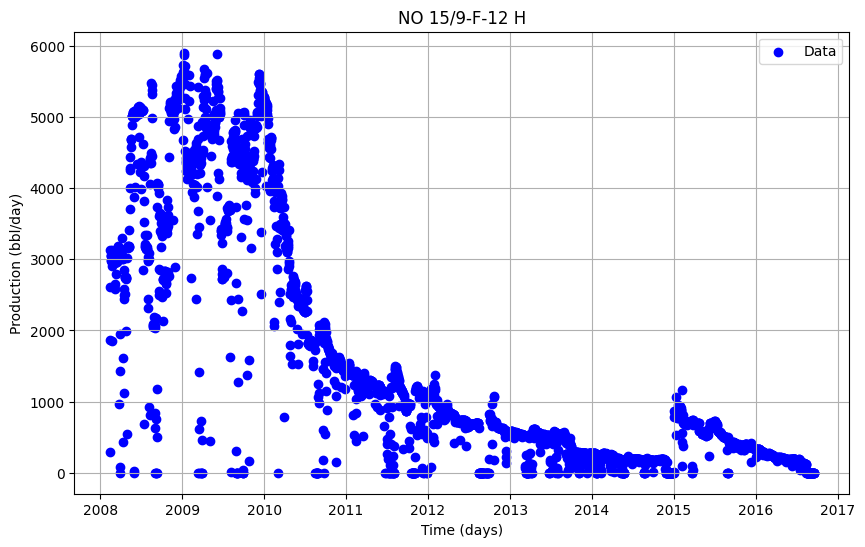

In [7]:
data = pd.read_excel("/home/rian/python_project/myvenv/dca_ml/data/Volve production data.xlsx")
data["DATEPRD"] = pd.to_datetime(data["DATEPRD"])

well_name = "NO 15/9-F-12 H"
data_sel = data.loc[data["WELL_BORE_CODE"] == well_name, ["WELL_BORE_CODE", "DATEPRD", "BORE_OIL_VOL"]].copy()
data_sel = data_sel.dropna(subset=["DATEPRD", "BORE_OIL_VOL"]).sort_values("DATEPRD")
data_sel.to_csv("/home/rian/python_project/myvenv/dca_ml/data/selected_data.csv", index=False)

plot_data(data_sel)

data_model = data_sel.rename(columns={"BORE_OIL_VOL": "q_oil"}).copy()
data_model["t"] = (data_model["DATEPRD"] - data_model["DATEPRD"].min()).dt.days
data_model['cum_oil'] = data_model['q_oil'].cumsum()

df_ml = make_features(data_model)

X = df_ml[['t',"q_lag1", "q_lag2", "q_lag3"]]
y = df_ml["q_oil"]

model = XGBRegressor(
    random_state=42,
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
)
model.fit(X, y)
y_fit = model.predict(X)



In [8]:
h = 1000
future_rates = []

last = df_ml.iloc[-1]
t0 = int(last["t"])

q1 = float(last["q_oil"])
q2 = float(last["q_lag1"])
q3 = float(last["q_lag2"])
cum = float(df_ml["cum_oil"].iloc[-1])

for i in range(1, h + 1):
    X_next = pd.DataFrame([{
        "t": t0 + i,
        "q_lag1": q1,
        "q_lag2": q2,
        "q_lag3": q3
    }])

    # ensure prediction columns match training features exactly
    X_next = X_next[X.columns]

    q_next = float(model.predict(X_next)[0])
    q_next = max(q_next, 0)

    future_rates.append(q_next)

    # shift
    q3, q2, q1 = q2, q1, q_next
    cum += q_next



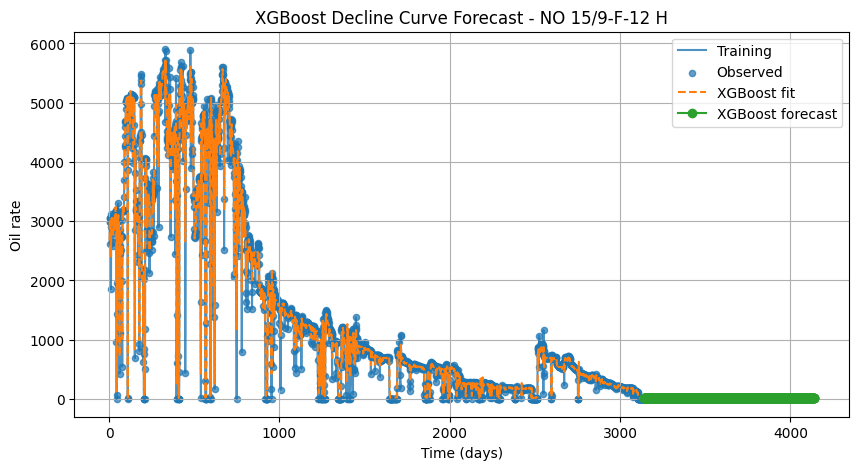

In [9]:
plt.figure(figsize=(10, 5))

# Plot training series as a line for easier trend comparison
plt.plot(df_ml["t"], df_ml["q_oil"], "-", label="Training", alpha=0.8)
plt.scatter(df_ml["t"], df_ml["q_oil"], s=20, label="Observed", alpha=0.7)
plt.plot(df_ml["t"], y_fit, "--", label="XGBoost fit")

forecast_plot = globals().get("forecast_data", None)

if forecast_plot is None or len(forecast_plot) == 0:
    forecast_plot = pd.DataFrame({
        "t": np.arange(t0 + 1, t0 + 1 + len(future_rates)),
        "q_oil": future_rates
    })

plt.plot(forecast_plot["t"], forecast_plot["q_oil"], "o-", label="XGBoost forecast")

plt.xlabel("Time (days)")
plt.ylabel("Oil rate")
plt.title(f"XGBoost Decline Curve Forecast - {well_name}")
plt.grid(True)
plt.legend()
plt.show()
